# NHC Wind Speed Probability Polygons

This notebook demonstrates how to use the functions in `src/ocha_lens/datasources/nhc_wsp.py`.

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

import ocha_lens as lens

### 1. Load a single archived issuance

Pass an issuance timestamp (YYYYMMDDHH or ISO format) to fetch a specific file from the NHC GIS archive. The returned GeoDataFrame has one row per (wind threshold, probability band).

In [2]:
# Hurricane Lee + Franklin active — 2023-08-22 00Z
gdf = lens.nhc_wsp.load_nhc_wsp(issuance="2023082200")
print(
    f"{len(gdf)} rows — {gdf['issuance'].nunique()} issuance, "
    f"{gdf['wind_threshold_kt'].nunique()} thresholds"
)
gdf.head()

33 rows — 1 issuance, 3 thresholds


,issuance,wind_threshold_kt,percentage,geometry
0,2023-08-22,34,<5%,"MULTIPOLYGON (((-95.95576 24.467, -95.95576 24..."
1,2023-08-22,34,5-10%,"MULTIPOLYGON (((-95.77594 25.05143, -95.77594 ..."
2,2023-08-22,34,10-20%,"MULTIPOLYGON (((-96.00072 25.36612, -96.00072 ..."
3,2023-08-22,34,20-30%,"MULTIPOLYGON (((-95.59612 25.68081, -95.59612 ..."
4,2023-08-22,34,30-40%,"MULTIPOLYGON (((-69.92627 13.4528, -69.92627 1..."


### 2. Plot the avocado chart

Reproduce the NHC avocado plot for a single wind threshold.

In [18]:
WSP_COLORS = {
    "<5%": "none",
    "5-10%": "#008B00",
    "10-20%": "#00CD00",
    "20-30%": "#7FFF00",
    "30-40%": "#FFFF00",
    "40-50%": "#FFD700",
    "50-60%": "#CD8500",
    "60-70%": "#FF7F00",
    "70-80%": "#CD0000",
    "80-90%": "#8B0000",
    ">90%": "#8B008B",
}


def plot_avocado(gdf, wind_threshold_kt=34, title="", ax=None):
    subset = gdf[
        (gdf["wind_threshold_kt"] == wind_threshold_kt)
        & gdf["geometry"].notna()
    ].copy()
    subset["fill"] = subset["percentage"].map(WSP_COLORS)

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    ax.set_facecolor("#d0e8f0")
    for _, row in subset.iterrows():
        if row["fill"] == "none" or row["geometry"] is None:
            continue
        import geopandas as gpd

        gpd.GeoDataFrame([row], geometry="geometry", crs=gdf.crs).plot(
            ax=ax, color=row["fill"], edgecolor="none"
        )

    bounds = subset["geometry"].total_bounds
    pad = 5
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

    legend_items = [(k, v) for k, v in WSP_COLORS.items() if v != "none"]
    handles = [
        mpatches.Patch(
            facecolor=color, edgecolor="#888", linewidth=0.3, label=label
        )
        for label, color in legend_items
    ]
    ax.legend(
        handles=handles,
        title="Probability",
        loc="lower left",
        fontsize=7,
        title_fontsize=7,
    )

    kt_label = {
        34: "≥34 kt (TS-force)",
        50: "≥50 kt",
        64: "≥64 kt (Hurricane)",
    }
    ax.set_title(
        f"NHC 5-Day Wind Probability — {kt_label[wind_threshold_kt]}\n{title}",
        fontsize=10,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    return ax

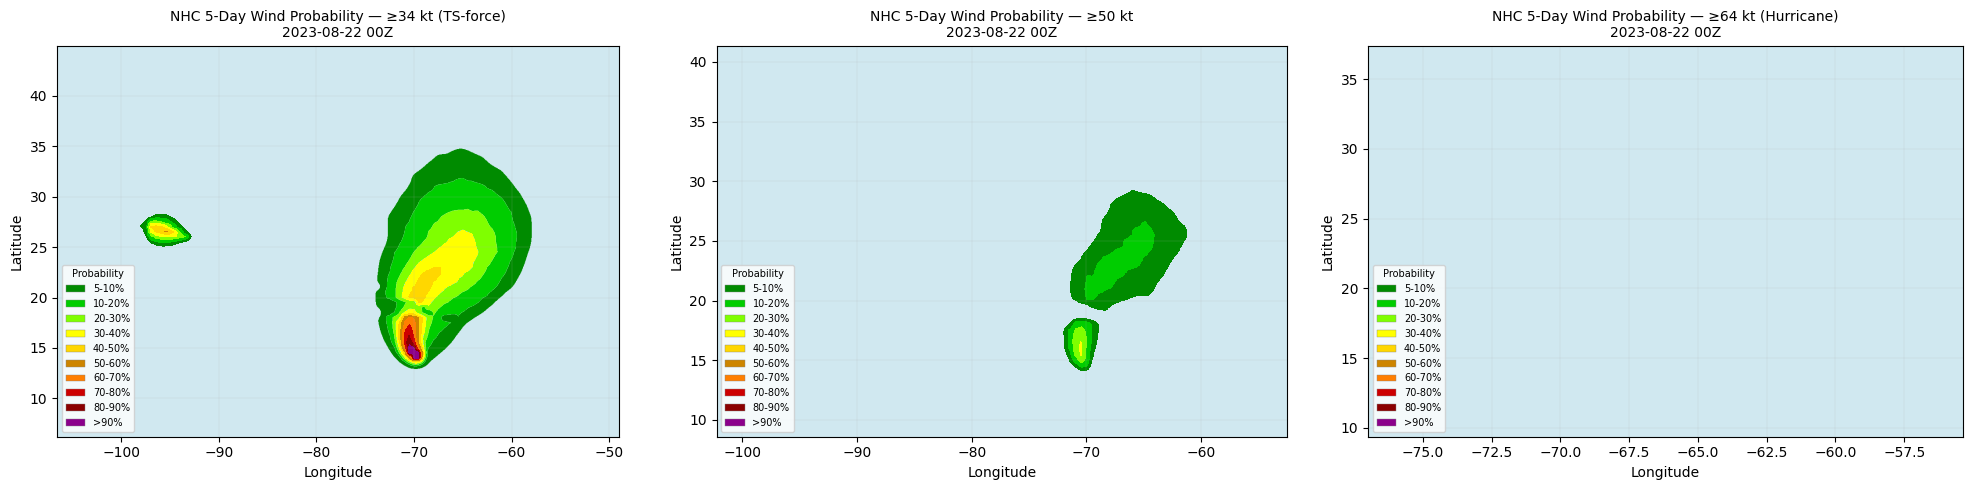

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
issuance_label = gdf["issuance"].iloc[0].strftime("%Y-%m-%d %HZ")
for ax, kt in zip(axes, [34, 50, 64]):
    plot_avocado(gdf, wind_threshold_kt=kt, title=issuance_label, ax=ax)
plt.tight_layout()
plt.show()

### 3. Archive backfill

In [6]:
# Fetch all issuances from the 2023 Atlantic hurricane season
gdf_season = lens.nhc_wsp.load_nhc_wsp(
    start="2023-11-15",
    end="2023-11-30",
    cache_dir="storm",
    use_cache=True,
)
print(
    f"{len(gdf_season)} rows across {gdf_season['issuance'].nunique()} issuances"
)

No 64kt shapefile found in zip
No 64kt shapefile found in zip


572 rows across 18 issuances


## 4. Build the storm–issuance link table

`get_nhc_wsp_storm_link()` maps issuance timestamps to the ATCF storm IDs that were active at that time. Pass the issuances from your archive GeoDataFrame to use the ATCF storm table for attribution.

In [7]:
issuances = list(gdf_season["issuance"].unique())
storm_link = lens.nhc_wsp.get_nhc_wsp_storm_link(issuances=issuances)
print(
    f"{len(storm_link)} rows — {storm_link['atcf_id'].nunique()} unique storms"
)
storm_link.head()

18 rows — 2 unique storms


,issuance,atcf_id
0,2023-11-16 18:00:00,AL222023
1,2023-11-17 00:00:00,AL222023
2,2023-11-17 06:00:00,AL222023
3,2023-11-17 12:00:00,AL222023
4,2023-11-17 18:00:00,AL222023


### 5. Filter polygons for a specific storm

Use the link table to find which issuances a given storm was active for, then filter the polygon GeoDataFrame to those issuances.

In [16]:
atcf_id = "AL222023"

active_issuances = storm_link.loc[storm_link["atcf_id"] == atcf_id, "issuance"]
wsp_lee = gdf_season[gdf_season["issuance"].isin(active_issuances)]

print(f"{active_issuances.nunique()} issuances covering {atcf_id}")
print(f"{len(wsp_lee)} polygon rows")

5 issuances covering AL222023
165 polygon rows


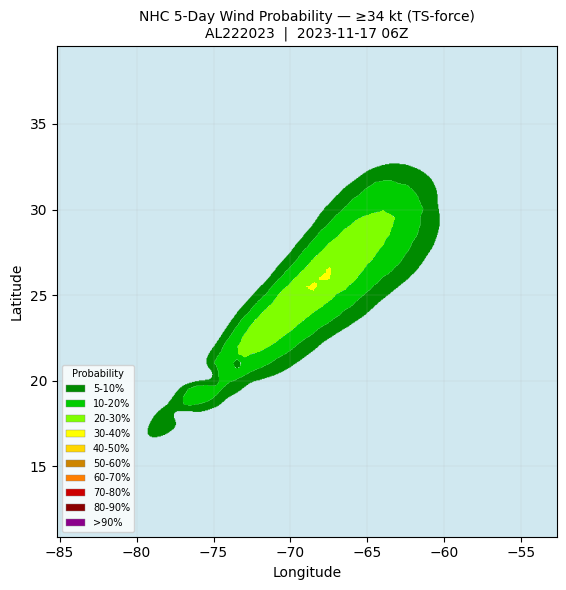

In [17]:
# Plot the 34kt polygons at a single issuance during the storm's lifetime
single_issuance = active_issuances.iloc[active_issuances.nunique() // 2]
wsp_lee_single = wsp_lee[wsp_lee["issuance"] == single_issuance]

plot_avocado(
    wsp_lee_single,
    wind_threshold_kt=34,
    title=f"{atcf_id}  |  {single_issuance.strftime('%Y-%m-%d %HZ')}",
)
plt.tight_layout()
plt.show()

### 6. Current mode (when storms are active)

In [ ]:
# Uncomment when storms are active
# gdf_current = lens.nhc_wsp.load_nhc_wsp()
# storm_link_current = lens.nhc_wsp.get_nhc_wsp_storm_link()
# print(gdf_current["issuance"].unique())
# print(storm_link_current)